# FAILSAFE — Step 2: Exploratory Data Analysis
**Goal:** Understand the dataset before touching any ML model.

We will:
1. Load and merge both student datasets
2. Inspect shape, columns, and data types
3. Create our target variable (pass/fail)
4. Visualise distributions and correlations
5. Identify key patterns that affect failure

## Cell 1 — Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Makes plots look clean and readable
sns.set_theme(style='darkgrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 100

print('All libraries loaded successfully!')

All libraries loaded successfully!


## Cell 2 — Load the data
The dataset uses semicolons (`;`) as separators, not commas.

In [6]:
import os
print(os.getcwd())                          # shows where Jupyter thinks you are
print(os.listdir('../data/raw/'))           # lists files in data/raw

C:\Users\Tanisha\failsafe\notebooks
['.gitkeep', '.ipynb_checkpoints', '.student.zip_old', 'student-mat.csv', 'student-merge.R', 'student-por.csv', 'student.txt', 'student.zip']


In [7]:
# Load both subject datasets
df_mat = pd.read_csv('../data/raw/student-mat.csv', sep=';')
df_por = pd.read_csv('../data/raw/student-por.csv', sep=';')

print(f'Math dataset:       {df_mat.shape[0]} students, {df_mat.shape[1]} columns')
print(f'Portuguese dataset: {df_por.shape[0]} students, {df_por.shape[1]} columns')

# Add a subject label before merging
df_mat['subject'] = 'math'
df_por['subject'] = 'portuguese'

# Merge into one combined dataset
df = pd.concat([df_mat, df_por], ignore_index=True)
print(f'\nCombined dataset:   {df.shape[0]} students, {df.shape[1]} columns')

Math dataset:       395 students, 33 columns
Portuguese dataset: 649 students, 33 columns

Combined dataset:   1044 students, 34 columns


## Cell 3 — First look at the data

In [8]:
# Show the first 5 rows
# Each row = one student, each column = one feature
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,subject
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,math
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,math
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,math
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,math
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,math


In [9]:
# Check data types and non-null counts
# 'object' dtype = text/category column
# 'int64' dtype = number column
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1044 entries, 0 to 1043
Data columns (total 34 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      1044 non-null   str  
 1   sex         1044 non-null   str  
 2   age         1044 non-null   int64
 3   address     1044 non-null   str  
 4   famsize     1044 non-null   str  
 5   Pstatus     1044 non-null   str  
 6   Medu        1044 non-null   int64
 7   Fedu        1044 non-null   int64
 8   Mjob        1044 non-null   str  
 9   Fjob        1044 non-null   str  
 10  reason      1044 non-null   str  
 11  guardian    1044 non-null   str  
 12  traveltime  1044 non-null   int64
 13  studytime   1044 non-null   int64
 14  failures    1044 non-null   int64
 15  schoolsup   1044 non-null   str  
 16  famsup      1044 non-null   str  
 17  paid        1044 non-null   str  
 18  activities  1044 non-null   str  
 19  nursery     1044 non-null   str  
 20  higher      1044 non-null   str  
 21  in

In [10]:
# Statistical summary of all numeric columns
# This shows min, max, mean, and quartiles
df.describe().round(2)

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,1044.00,1044.00,1044.00,1044.00,1044.00,1044.00,1044.00,1044.00,1044.00,1044.00,1044.00,1044.00,1044.00,1044.00,1044.00,1044.00
mean,16.73,2.60,2.39,1.52,1.97,0.26,3.94,3.20,3.16,1.49,2.28,3.54,4.43,11.21,11.25,11.34
std,1.24,1.12,1.10,0.73,0.83,0.66,0.93,1.03,1.15,0.91,1.29,1.42,6.21,2.98,3.29,3.86
min,15.00,0.00,0.00,1.00,1.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00
25%,16.00,2.00,1.00,1.00,1.00,0.00,4.00,3.00,2.00,1.00,1.00,3.00,0.00,9.00,9.00,10.00
50%,17.00,3.00,2.00,1.00,2.00,0.00,4.00,3.00,3.00,1.00,2.00,4.00,2.00,11.00,11.00,11.00
75%,18.00,4.00,3.00,2.00,2.00,0.00,5.00,4.00,4.00,2.00,3.00,5.00,6.00,13.00,13.00,14.00
max,22.00,4.00,4.00,4.00,4.00,3.00,5.00,5.00,5.00,5.00,5.00,5.00,75.00,19.00,19.00,20.00


## Cell 4 — Check for missing values

In [11]:
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values — great!')

Missing values per column:
No missing values — great!


## Cell 5 — Create the target variable (pass/fail)
G3 is the final grade (0–20). We define:
- **fail = 1** if G3 < 10 (student is at risk)
- **pass = 0** if G3 >= 10

In [12]:
# Create binary target: 1 = at risk (fail), 0 = pass
df['at_risk'] = (df['G3'] < 10).astype(int)

# How many students are at risk?
counts = df['at_risk'].value_counts()
pct_at_risk = (counts[1] / len(df) * 100).round(1)

print(f'Total students : {len(df)}')
print(f'Passing (0)    : {counts[0]} ({100 - pct_at_risk}%)')
print(f'At risk (1)    : {counts[1]} ({pct_at_risk}%)')
print(f'\nClass imbalance ratio: {(counts[0]/counts[1]):.1f}:1')
print('NOTE: This imbalance is why we will use SMOTE and F1-score later.')

Total students : 1044
Passing (0)    : 814 (78.0%)
At risk (1)    : 230 (22.0%)

Class imbalance ratio: 3.5:1
NOTE: This imbalance is why we will use SMOTE and F1-score later.


## Cell 6 — Visualise class imbalance

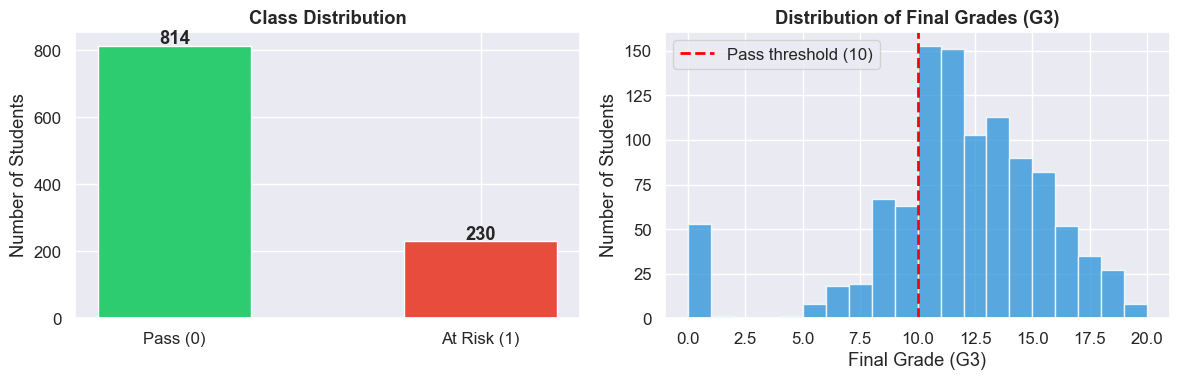

Chart saved to reports/


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart of pass vs fail
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['Pass (0)', 'At Risk (1)'], counts.values, color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Number of Students')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Distribution of final grades G3
axes[1].hist(df['G3'], bins=20, color='#3498db', edgecolor='white', alpha=0.8)
axes[1].axvline(x=10, color='red', linestyle='--', linewidth=2, label='Pass threshold (10)')
axes[1].set_title('Distribution of Final Grades (G3)', fontweight='bold')
axes[1].set_xlabel('Final Grade (G3)')
axes[1].set_ylabel('Number of Students')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/01_class_distribution.png', bbox_inches='tight')
plt.show()
print('Chart saved to reports/')

## Cell 7 — Key feature: Absences vs Failure

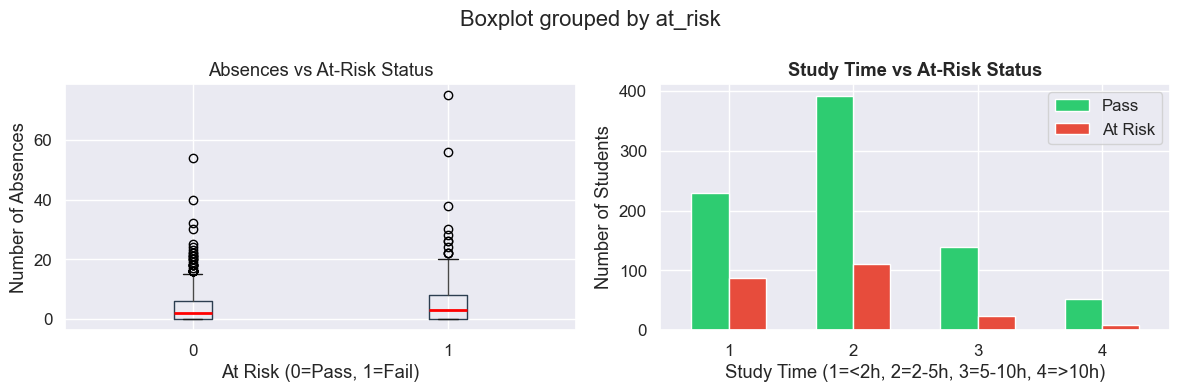

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Absences by pass/fail
df.boxplot(column='absences', by='at_risk', ax=axes[0],
           boxprops=dict(color='#2c3e50'),
           medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Absences vs At-Risk Status', fontweight='bold')
axes[0].set_xlabel('At Risk (0=Pass, 1=Fail)')
axes[0].set_ylabel('Number of Absences')
plt.sca(axes[0])
plt.title('Absences vs At-Risk Status')

# Study time by pass/fail
study_risk = df.groupby(['studytime', 'at_risk']).size().unstack(fill_value=0)
study_risk.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'],
                edgecolor='white', width=0.6)
axes[1].set_title('Study Time vs At-Risk Status', fontweight='bold')
axes[1].set_xlabel('Study Time (1=<2h, 2=2-5h, 3=5-10h, 4=>10h)')
axes[1].set_ylabel('Number of Students')
axes[1].legend(['Pass', 'At Risk'])
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../reports/02_absences_studytime.png', bbox_inches='tight')
plt.show()

## Cell 8 — Previous grades G1 and G2 as predictors

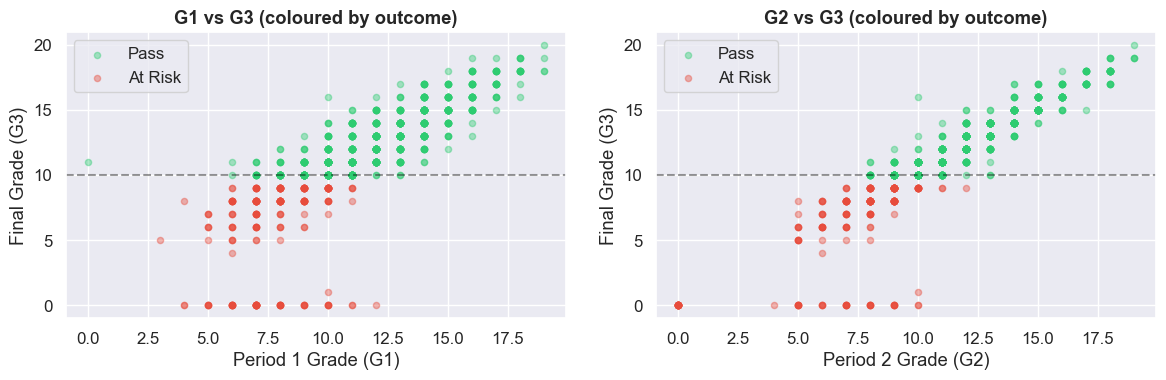

Key insight: G1 and G2 are strong predictors of G3 — early warning is possible!


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Scatter: G1 vs G3 coloured by at_risk
for risk, color, label in [(0, '#2ecc71', 'Pass'), (1, '#e74c3c', 'At Risk')]:
    mask = df['at_risk'] == risk
    axes[0].scatter(df[mask]['G1'], df[mask]['G3'],
                    alpha=0.4, c=color, label=label, s=20)
axes[0].set_xlabel('Period 1 Grade (G1)')
axes[0].set_ylabel('Final Grade (G3)')
axes[0].set_title('G1 vs G3 (coloured by outcome)', fontweight='bold')
axes[0].legend()
axes[0].axhline(y=10, color='black', linestyle='--', alpha=0.4, label='Pass line')

# Scatter: G2 vs G3
for risk, color, label in [(0, '#2ecc71', 'Pass'), (1, '#e74c3c', 'At Risk')]:
    mask = df['at_risk'] == risk
    axes[1].scatter(df[mask]['G2'], df[mask]['G3'],
                    alpha=0.4, c=color, label=label, s=20)
axes[1].set_xlabel('Period 2 Grade (G2)')
axes[1].set_ylabel('Final Grade (G3)')
axes[1].set_title('G2 vs G3 (coloured by outcome)', fontweight='bold')
axes[1].legend()
axes[1].axhline(y=10, color='black', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('../reports/03_grade_progression.png', bbox_inches='tight')
plt.show()
print('Key insight: G1 and G2 are strong predictors of G3 — early warning is possible!')

## Cell 9 — Correlation heatmap (numeric features only)

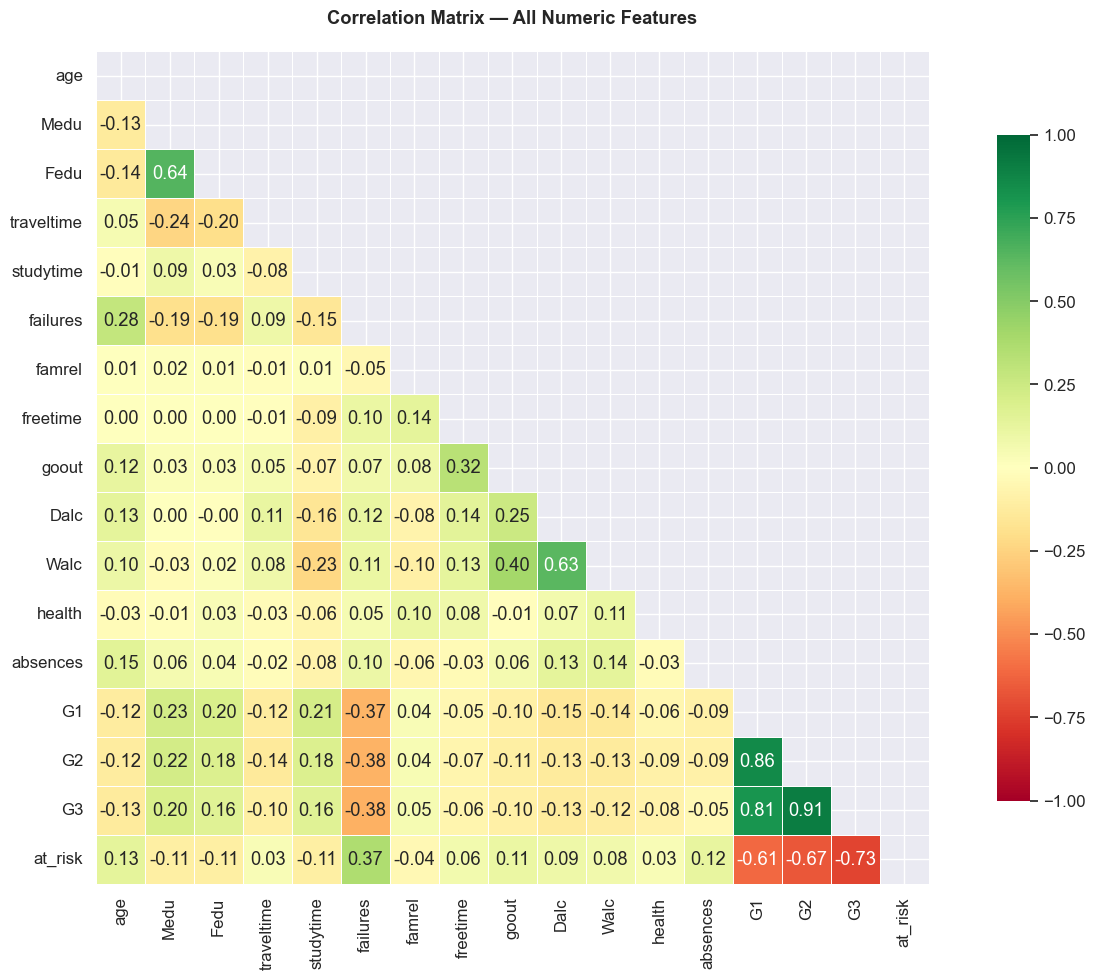

In [16]:
# Select only numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(14, 10))
corr_matrix = df[numeric_cols].corr()

# Mask the upper triangle so we don't duplicate
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})

plt.title('Correlation Matrix — All Numeric Features', fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../reports/04_correlation_heatmap.png', bbox_inches='tight')
plt.show()

## Cell 10 — Top correlations with at_risk

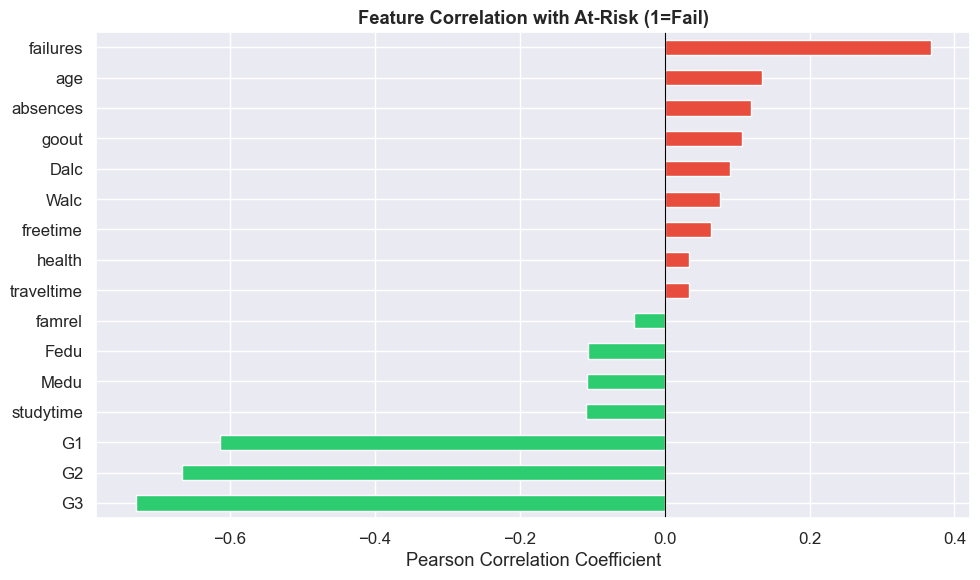


Top risk INCREASING features (red):
failures    0.367183
age         0.134276
absences    0.119142
goout       0.106506

Top risk DECREASING features (green):
G3          -0.729693
G2          -0.666289
G1          -0.613927
studytime   -0.108553
Medu        -0.106460
Fedu        -0.105579


In [17]:
# Which features correlate most strongly with failing?
correlations = df[numeric_cols].corr()['at_risk'].drop('at_risk').sort_values()

plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in correlations.values]
correlations.plot(kind='barh', color=colors, edgecolor='white')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Feature Correlation with At-Risk (1=Fail)', fontweight='bold')
plt.xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.savefig('../reports/05_feature_correlations.png', bbox_inches='tight')
plt.show()

print('\nTop risk INCREASING features (red):')
print(correlations[correlations > 0.1].sort_values(ascending=False).to_string())
print('\nTop risk DECREASING features (green):')
print(correlations[correlations < -0.1].sort_values().to_string())

## Cell 11 — Family and social factors

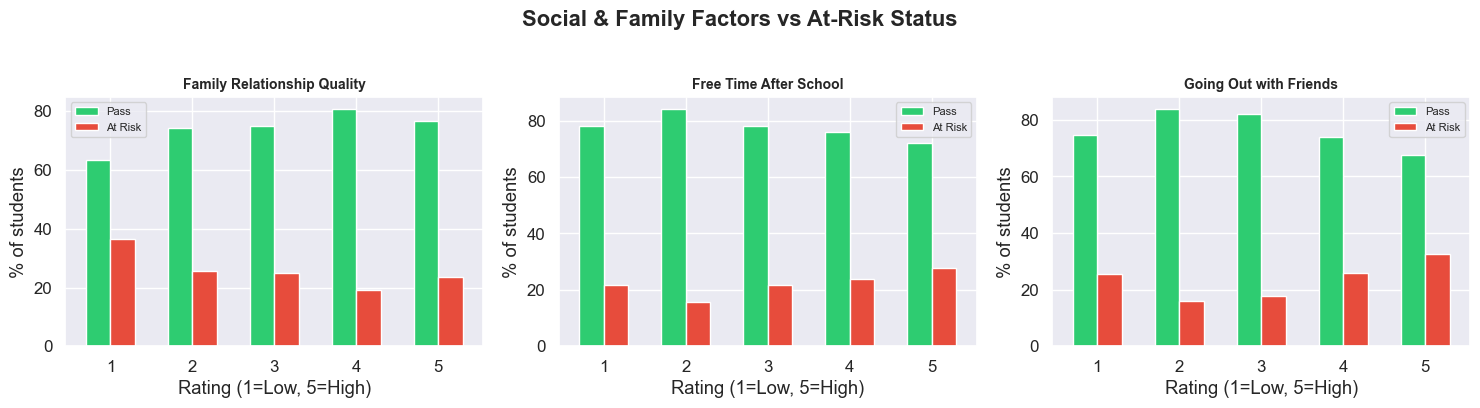

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

cat_features = ['famrel', 'freetime', 'goout']
titles = ['Family Relationship Quality', 'Free Time After School', 'Going Out with Friends']

for ax, feat, title in zip(axes, cat_features, titles):
    data = df.groupby([feat, 'at_risk']).size().unstack(fill_value=0)
    data_pct = data.div(data.sum(axis=1), axis=0) * 100
    data_pct.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'],
                  edgecolor='white', width=0.6)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlabel('Rating (1=Low, 5=High)')
    ax.set_ylabel('% of students')
    ax.legend(['Pass', 'At Risk'], fontsize=8)
    ax.tick_params(axis='x', rotation=0)

plt.suptitle('Social & Family Factors vs At-Risk Status', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/06_social_factors.png', bbox_inches='tight')
plt.show()

## Cell 12 — Save cleaned data for next step

In [19]:
# Save the combined dataset with our target variable
df.to_csv('../data/processed/students_combined.csv', index=False)
print(f'Saved {len(df)} rows to data/processed/students_combined.csv')
print(f'Columns: {list(df.columns)}')
print('\n--- EDA COMPLETE ---')
print('Key findings:')
print(f'  - {pct_at_risk}% of students are at risk of failing')
print('  - G1 and G2 (prior grades) are the strongest predictors')
print('  - High absences strongly correlate with failure')
print('  - Low study time increases risk')
print('  - Social factors (goout, freetime) show moderate correlation')
print('\nReady for Step 3: Preprocessing!')

Saved 1044 rows to data/processed/students_combined.csv
Columns: ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3', 'subject', 'at_risk']

--- EDA COMPLETE ---
Key findings:
  - 22.0% of students are at risk of failing
  - G1 and G2 (prior grades) are the strongest predictors
  - High absences strongly correlate with failure
  - Low study time increases risk
  - Social factors (goout, freetime) show moderate correlation

Ready for Step 3: Preprocessing!
